<a href="https://colab.research.google.com/github/tomas-kaunas/Money/blob/main/Meta_Stock_Forecasting_using_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Meta Stock Forecasting using TensorFlow

Project: META Stock Price Forecasting with Deep Learning

This project involves acquiring historical stock market actions for Meta Platforms, Inc. (META) and developing a time-series forecasting pipeline using a Long Short-Term Memory (LSTM) Recurrent Neural Network to predict next-day closing stock values based on historical sequence data.

Key quantitative & machine learning skills demonstrated:
- Market Data Acquisition & Ingestion (Yahoo Finance API)
- Exploratory Time-Series Visualization & Plotting (Matplotlib)
- Bounded Feature Scaling & Normalization (MinMaxScaler)
- Time-Series Sequence Engineering (Lookback Windows & Tensors)
- Recurrent Neural Network Design (LSTM Layers via Keras)
- Out-of-Sample Strategy Backtesting & Forecast Realization
- Error Tracking Evaluation (Mean Squared Error & Root Mean Squared Error)

The goal is to capture multi-day temporal trends across asset pricing histories to predict next-day market values and evaluate the pipeline's generalization capability.


## ENVIRONMENT SETUP & DECURSIVE WARNING CONTROL

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

##DATA INGESTION & DATA DUMP LOCAL STORAGE

In [2]:
import yfinance as yf
ticker = "META"
start_date = "2010-01-10"
end_date = "2025-09-10"

data = yf.download(ticker, start=start_date, end=end_date)
data = data.reset_index()
ohlcv = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
ohlcv.to_csv("META_OHLCV.csv")
data = pd.read_csv("META_OHLCV.csv", parse_dates=["Date"])

cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce')
print(data.info())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   3347 non-null   object        
 1   Date    3346 non-null   datetime64[ns]
 2   Open    3346 non-null   float64       
 3   High    3346 non-null   float64       
 4   Low     3346 non-null   float64       
 5   Close   3346 non-null   float64       
 6   Volume  3346 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 183.2+ KB
None


##EXPLORATORY DATA ANALYSIS & HISTORICAL VISUALIZATION

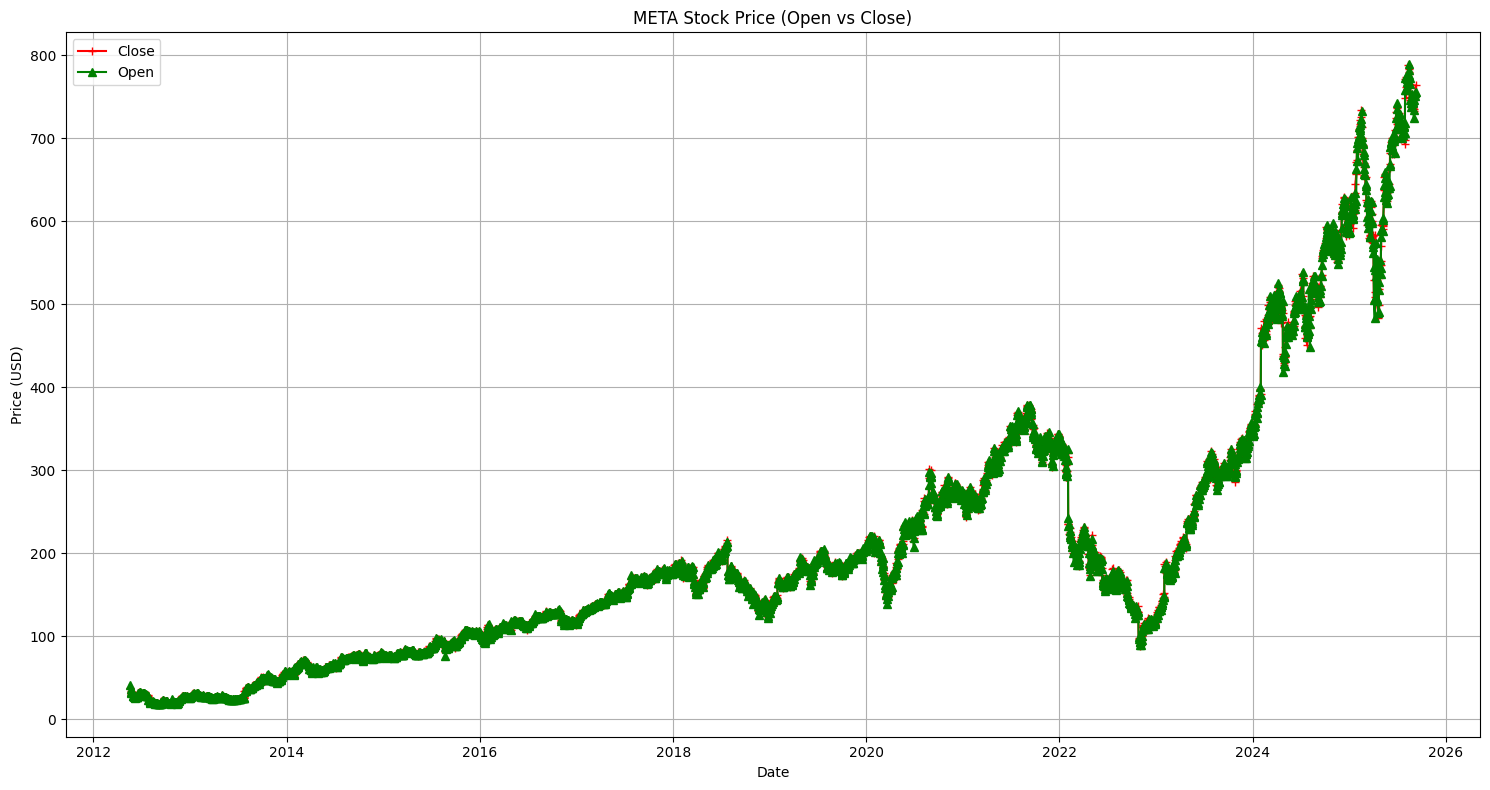

In [4]:

plt.figure(figsize=(15, 8))
plt.plot(data['Date'], data['Close'], color="red", label="Close", marker="+")
plt.plot(data['Date'], data['Open'], color="green", label="Open", marker="^")
plt.title("META Stock Price (Open vs Close)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


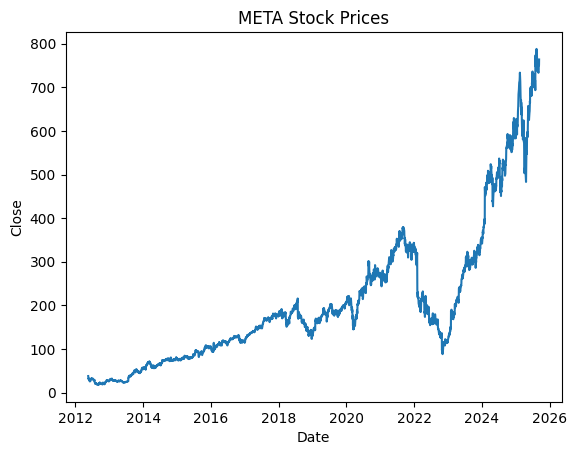

In [5]:

meta = data
prediction_range = meta.loc[(meta['Date'] > datetime(2013,1,1))
 & (meta['Date']<datetime(2018,1,1))]
plt.plot(meta['Date'], meta['Close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("META Stock Prices")
plt.show()

In [6]:
meta = meta[1:]
close_data = meta.filter(['Close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))
print(dataset)

[[ 37.93233109]
 [ 33.76502991]
 [ 30.75862122]
 ...
 [750.68707275]
 [750.53735352]
 [763.90600586]]


##DATA TRANSFORMATION & LOOKBACK SEQUENCE CONSTRUCTIONS

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])


x_train, y_train = np.array(x_train), np.array(y_train)
print(x_train.shape)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

(3119, 60)


##DEEP LEARNING LSTM NETWORK ASSEMBLY & OPTIMIZATION

In [8]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(units=64,
                            return_sequences=True,
                            input_shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

##MODEL FORECASTING & ERROR-METRIC TRACKING

In [22]:
model.compile(optimizer='adam',
              loss='mean_squared_error')
history = model.fit(x_train,
                    y_train,
                    epochs=25)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0010    
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.1727e-04
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.4066e-04
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0010
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010    
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.9118e-04
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.9098e-04
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.3101e-04
Epoch 9/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.8725e-04
Epoch 10/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.9487e-04
Epoch 11/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010
Epoch 12/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.7735e-04
Epoch 13/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010
Epoch 14/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.4413e-04
Epoch 15/25
98/98 ━━━━━━━━━━━━━━━━━━━

In [23]:
test_data = scaled_data[training - 60:, :]
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

mse = np.mean(((predictions - y_test) ** 2))
rmse = np.sqrt(mse)

print("MSE", mse)
print("RMSE", np.sqrt(mse))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
MSE 321.4084722976741
RMSE 17.92786859327327


##VISUAL PERFORMANCE RUNS & STRATEGY BENCHMARKING

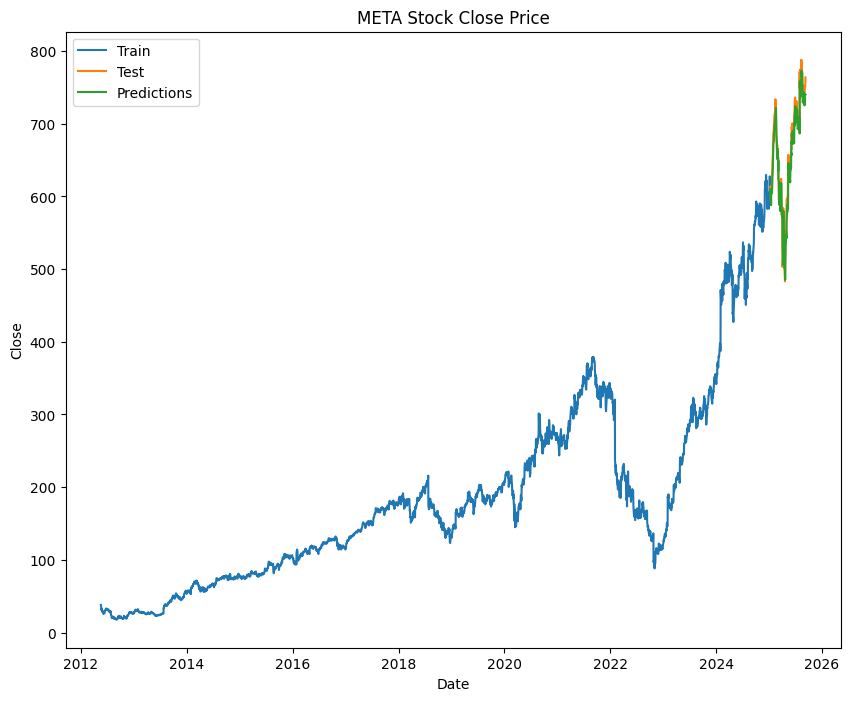

In [24]:
train = meta[:training]
test = meta[training:]
test['Predictions'] = predictions

plt.figure(figsize=(10, 8))
plt.plot(train['Date'], train['Close'])
plt.plot(test['Date'], test[['Close', 'Predictions']])
plt.title('META Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])

## LIVE INFERENCE PIPELINE (NEXT-DAY FORECAST WINDOW)

In [29]:
test = [scaled_data[-59:, :]]
test = np.array(test)
test = np.reshape(test, (test.shape[0], test.shape[1], 1))

prediction = model(test, training=False).numpy()

prediction = scaler.inverse_transform(prediction)
print(prediction)

[[752.3066]]
